# **Install Roboflow**


In [ ]:
!pip install roboflow

# **Download Dataset from Roboflow**

In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="tXr10qCHwVjmdrbIAB2m")
project = rf.workspace("vaishnavi8mu4s").project("waste-segregation-3xph4")
version = project.version(5)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to waste-segregation-5 in folder:: 100%|██████████| 2647/2647 [00:02<00:00, 1264.53it/s]


# **Rename Dataset Folder**

In [3]:
import os

old_name = 'waste-segregation-5'
new_name = 'Waste_Classification_Datasets'

if os.path.exists(old_name) and not os.path.exists(new_name):
    os.rename(old_name, new_name)
    print("Folder renamed successfully.")
else:
    print("Rename skipped (source not found or already renamed).")


Folder renamed successfully.


# **Import Libraries**

In [4]:
import pandas as pd
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image

torch.cuda.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# **Define Directries**

In [8]:
train_dir = 'Waste_Classification_Datasets/train'

# **Create the datasets class**

In [9]:
import os
from PIL import Image
from torch.utils.data import Dataset

class ImageFolderDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        # Get class names from folder names
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        # Collect all image paths + labels
        self.samples = []
        for cls in self.classes:
            cls_folder = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_folder):
                continue

            for img_name in os.listdir(cls_folder):
                img_path = os.path.join(cls_folder, img_name)
                self.samples.append((img_path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path)

        if self.transforms:
            img = self.transforms(img)

        return img, label


# **Plot bar graph**

{'Hazardous': 473, 'Non-recyclable': 445, 'Recyclable': 460, 'Organic': 469}


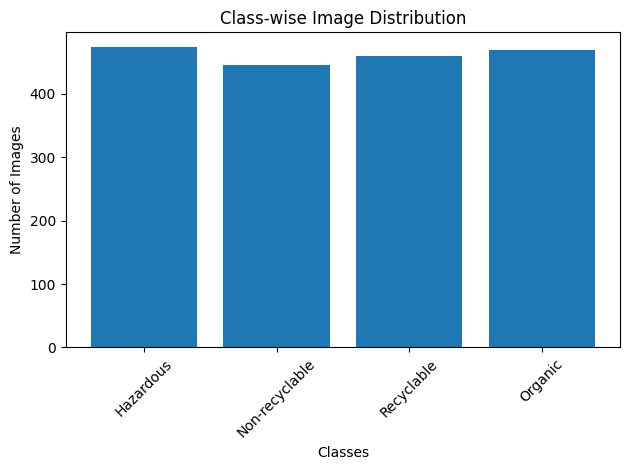

In [ ]:
import os
import matplotlib.pyplot as plt


count_dict = {}

# Loop over class folders
for fld in os.listdir(train_dir):
    fld_path = os.path.join(train_dir, fld)

    if os.path.isdir(fld_path):
        img_count = len(os.listdir(fld_path))
        count_dict[fld] = img_count

print(count_dict)

# -------- BAR GRAPH --------
classes = list(count_dict.keys())
counts = list(count_dict.values())

plt.figure()
plt.bar(classes, counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class-wise Image Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# **Create the datsets**

In [10]:
from torch.utils.data import DataLoader

transformation = transforms.Compose([
    transforms.Resize((60,60)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])


train_dataset = ImageFolderDataset(
    root_dir=train_dir,
    transforms=transformation
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.


# **Get the length**

In [ ]:
print(train_dataset.__getitem__(0)[0].shape)

torch.Size([3, 60, 60])


In [ ]:
print(len(train_loader))

58


# **Plot the images**

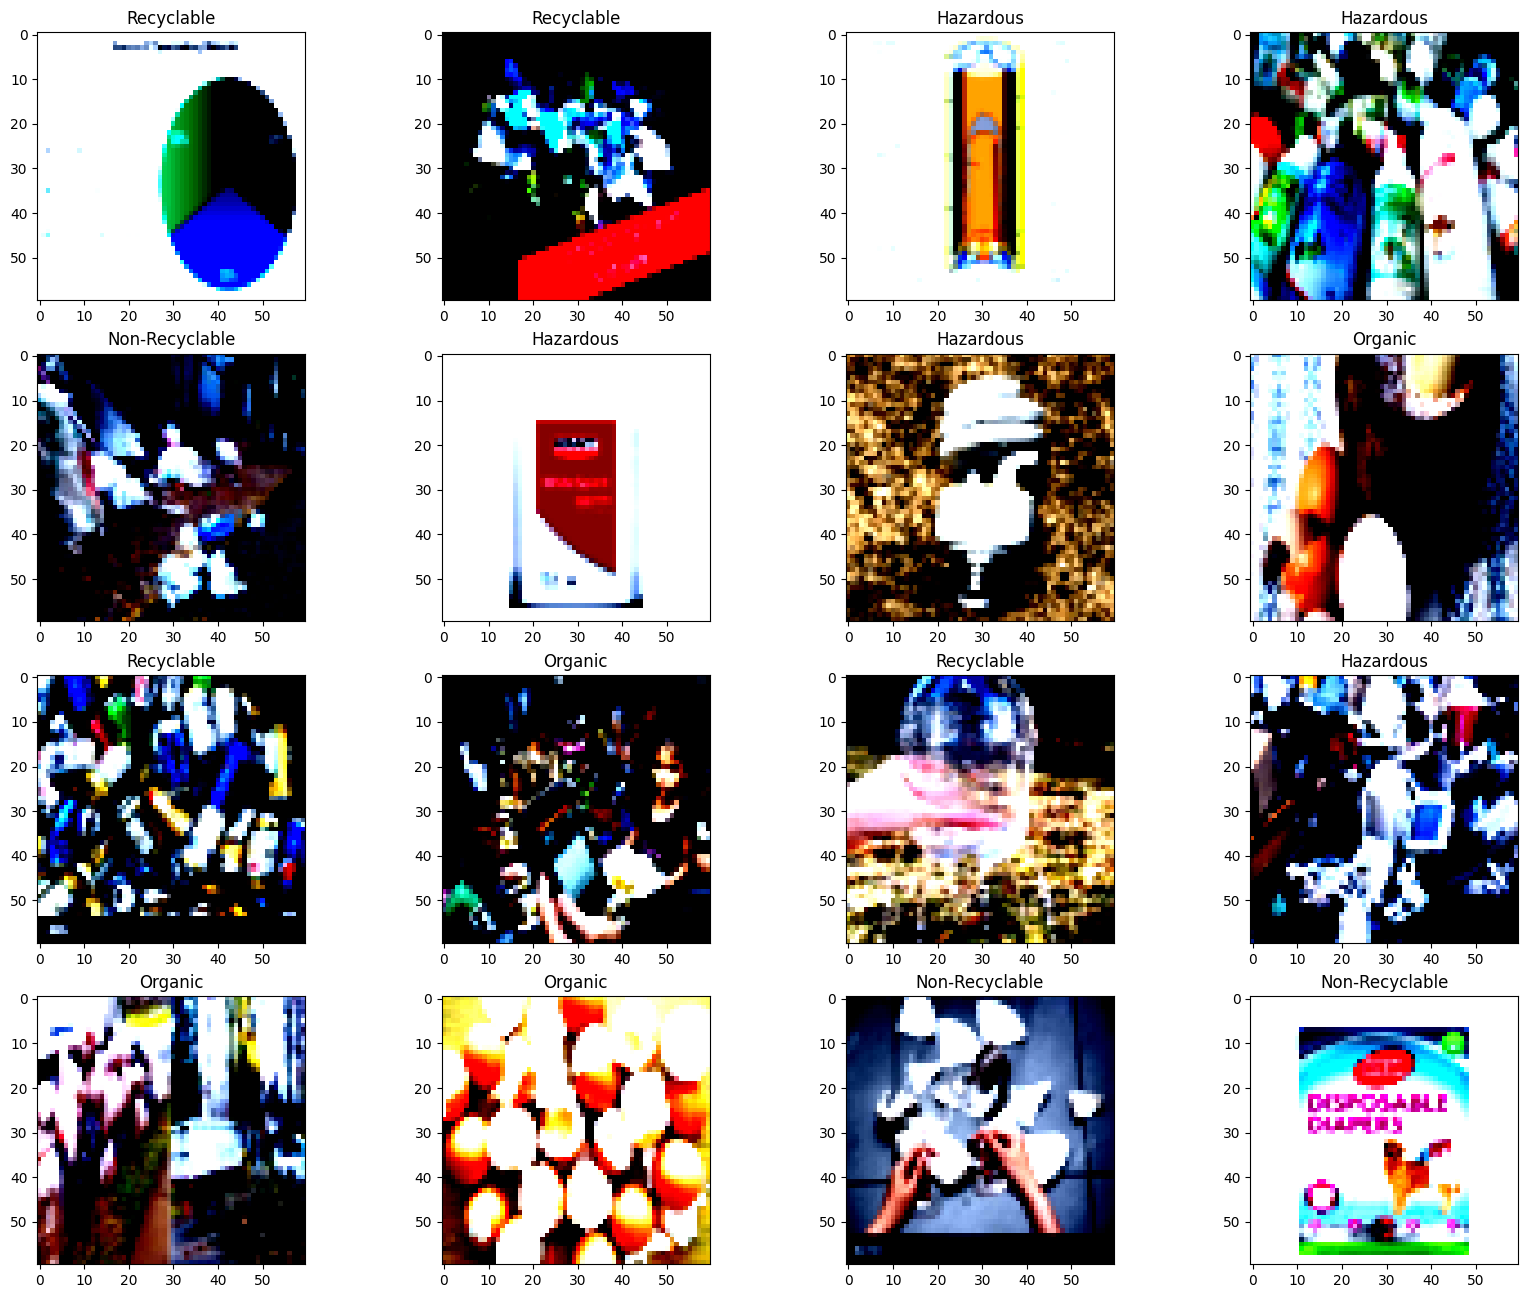

In [ ]:
samples,labels = next(iter(train_loader))

fig, axes = plt.subplots(4,4,figsize=(20,16))
axes = axes.ravel()

class_names = ['Hazardous','Non-Recyclable','Organic','Recyclable']

for i in range(16):
    label = class_names[labels[i].item()]
    axes[i].imshow(samples[i].permute(1,2,0))  ## (C,H,W) to (H,W,C)
    axes[i].set_title(label)

# **Create the CNN model**

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) # (60 + 2 *0 -3 / 1) + 1 = 58*58*16
        self.pool1 = nn.MaxPool2d(2) # (58 + 2 *0 -2 / 2) + 1 = 29*29*16

        self.conv2 = nn.Conv2d(16, 32, 3) # (29 + 2 *0 -3 / 1) + 1 = 27*27*32
        self.pool2 = nn.MaxPool2d(2) # (27 + 2 *0 -2 / 2) + 1 = 13*13*32

        self.conv3 = nn.Conv2d(32, 64, 3) # (13 + 2 *0 -3 / 1) + 1 = 11*11*64
        self.pool3 = nn.MaxPool2d(2)   # (11 + 2 *0 -2 / 2) + 1 = 5*5*64

        self.flatten = nn.Flatten() # 5*5*64 = 1600

        self.fc1 = nn.Linear(64*5*5,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,4)

    def forward(self,x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.pool3(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)
        x = F.relu(x)

        x = self.fc3(x)

        return x

model = CNN().to(device)

# **Get the model summary**

In [ ]:
from torchsummary import summary
summary(model, (3,60,60)) # (C,H,W)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 58, 58]             448
         MaxPool2d-2           [-1, 16, 29, 29]               0
            Conv2d-3           [-1, 32, 27, 27]           4,640
         MaxPool2d-4           [-1, 32, 13, 13]               0
            Conv2d-5           [-1, 64, 11, 11]          18,496
         MaxPool2d-6             [-1, 64, 5, 5]               0
           Flatten-7                 [-1, 1600]               0
            Linear-8                  [-1, 256]         409,856
            Linear-9                  [-1, 128]          32,896
           Linear-10                    [-1, 4]             516
Total params: 466,852
Trainable params: 466,852
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.04
Forward/backward pass size (MB): 0.82
Params size (MB): 1.78
Estimated T

# **Define optimizers**

In [ ]:
criterian = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0006)
epochs = 50

# **Define model training**

In [ ]:
from tqdm import tqdm

train_loss = []
train_accuracy = []

for epoch in range(epochs):
    model.train()
    correct = 0
    running_loss = 0.0
    total_samples = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{epochs}]",
        leave=True
    )

    for data, labels in progress_bar:
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterian(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = 100 * correct / total_samples

    train_loss.append(epoch_loss)
    train_accuracy.append(epoch_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Training Loss: {epoch_loss:.4f} "
        f"Training Accuracy: {epoch_acc:.2f}%"
    )


Epoch [1/50]: 100%|██████████| 58/58 [00:16<00:00,  3.42it/s]


Epoch [1/50] Training Loss: 1.3375 Training Accuracy: 32.16%


Epoch [2/50]: 100%|██████████| 58/58 [00:14<00:00,  4.00it/s]


Epoch [2/50] Training Loss: 1.2869 Training Accuracy: 37.79%


Epoch [3/50]: 100%|██████████| 58/58 [00:12<00:00,  4.75it/s]


...

Epoch [48/50] Training Loss: 0.0005 Training Accuracy: 100.00%


Epoch [49/50]: 100%|██████████| 58/58 [00:12<00:00,  4.72it/s]


Epoch [49/50] Training Loss: 0.0005 Training Accuracy: 100.00%


Epoch [50/50]: 100%|██████████| 58/58 [00:12<00:00,  4.73it/s]

Epoch [50/50] Training Loss: 0.0004 Training Accuracy: 100.00%


# **Plot the graph**

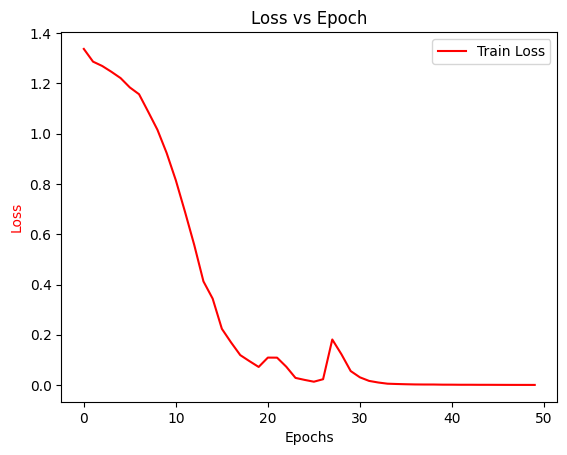

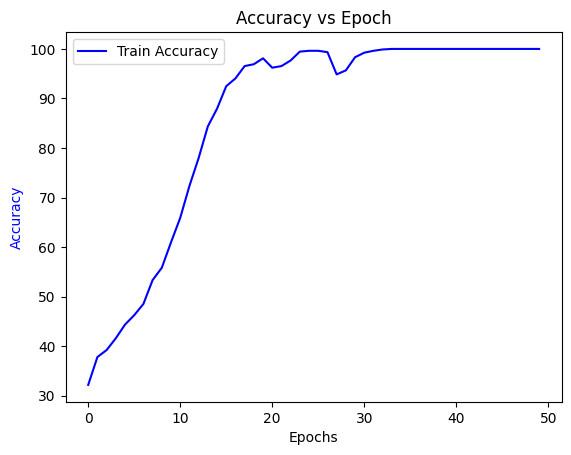

In [ ]:
epoch_log = [*range(epochs)]

fig,ax1 = plt.subplots()
ax1.plot(epoch_log,train_loss,'r-',label = 'Train Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss',color='r')
ax1.set_title('Loss vs Epoch')
ax1.legend()
plt.show()

fig,ax2 = plt.subplots()
ax2.plot(epoch_log,train_accuracy,'b-',label = 'Train Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy',color='b')
ax2.set_title('Accuracy vs Epoch')
ax2.legend()
plt.show()

# **Save the model**

In [ ]:
path = 'waste.pth'
torch.save(model.state_dict(), path)

In [ ]:
from google.colab import files
files.download('waste.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Load the model**

In [6]:
model.load_state_dict(torch.load("model.pth", map_location=device))
model.to(device)
model.eval()   # or model.train()


CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1600, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)

# **Plot the images**

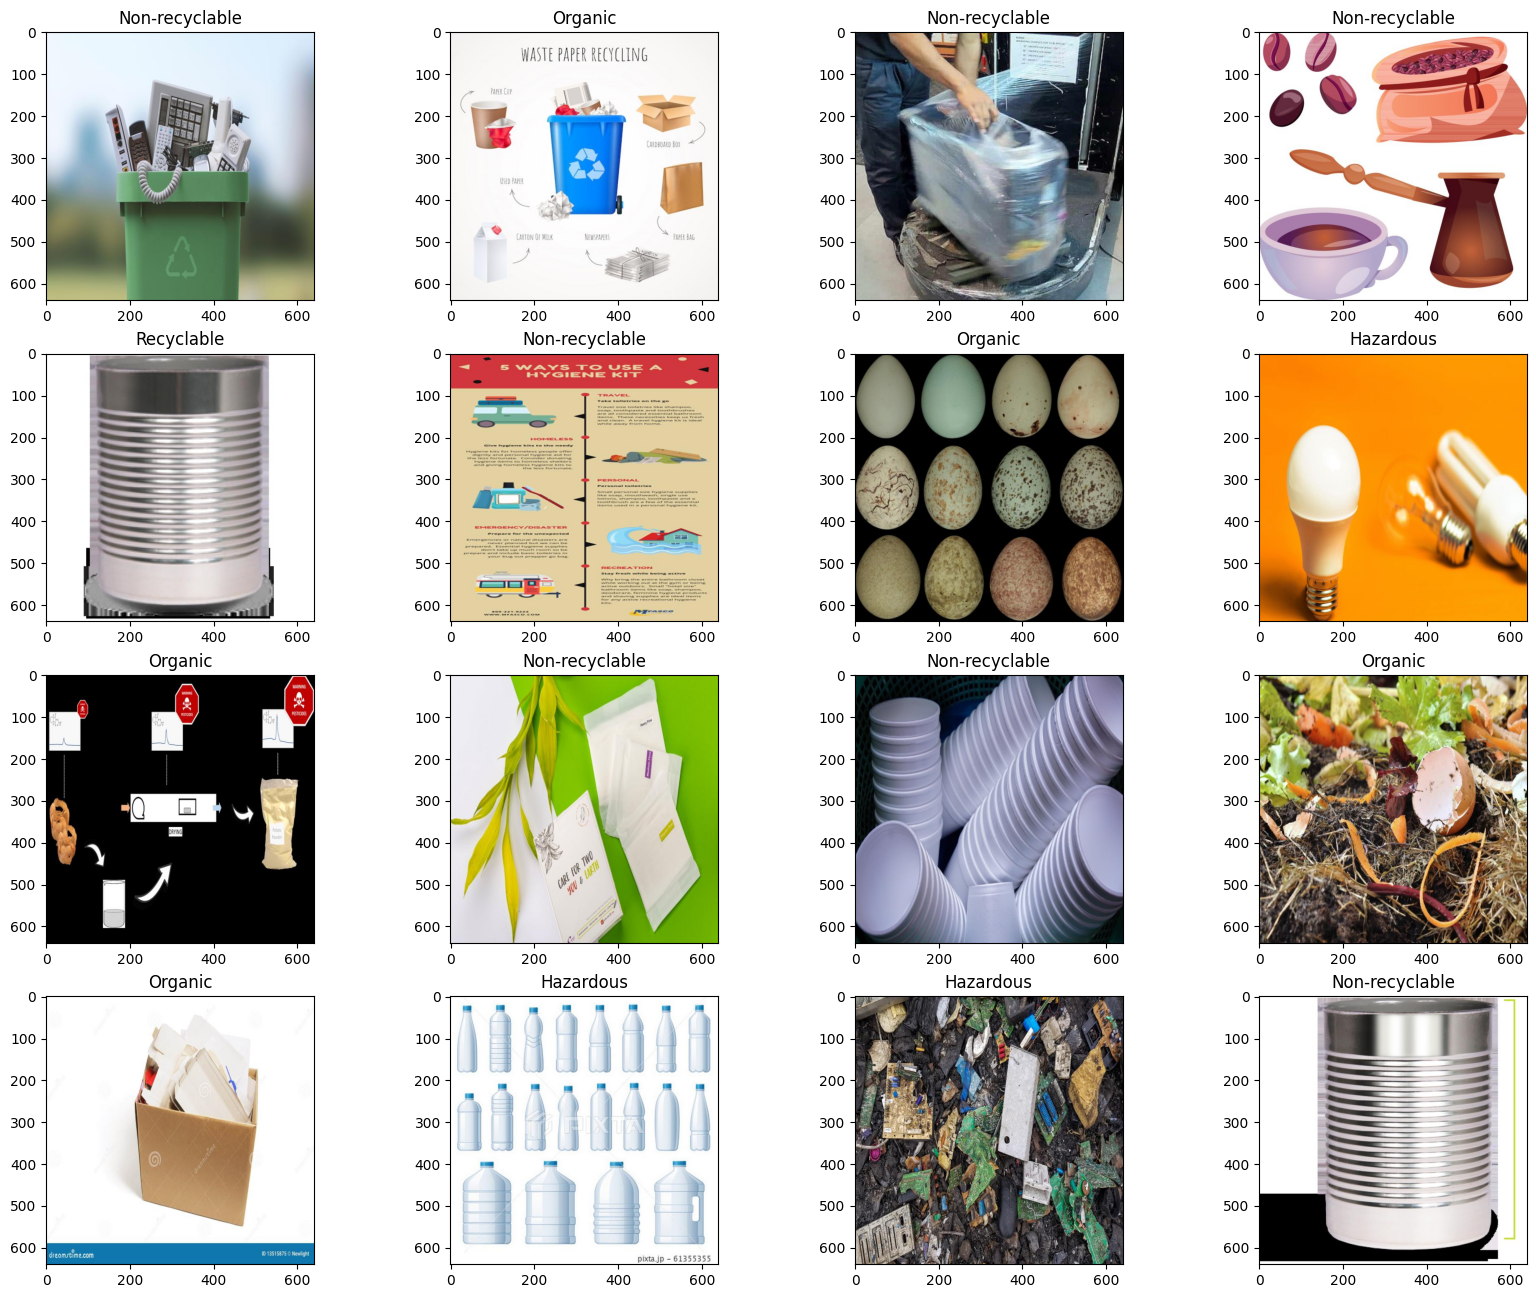

In [12]:
import random


test_dir = 'Waste_Classification_Datasets/test'
test_flds = os.listdir(test_dir)

def preprocessing(image):
    img = transformation(image) ##  (c,h,w) required == (b,c,h,w) ==> (1,3,60,60)
    img = img.unsqueeze(0)
    return img

fig, axes = plt.subplots(4,4,figsize=(20,16))
axes = axes.ravel()

class_names = train_dataset.classes

for i in range(16):
    fld = random.choice(test_flds)
    fld_path = os.path.join(test_dir,fld)
    img_list = os.listdir(fld_path)
    img_path = os.path.join(test_dir,fld, random.choice(img_list))
    image = Image.open(img_path)
    preprocessed_img = preprocessing(image)

    output = model(preprocessed_img.to(device))
    pred = torch.argmax(output).item()
    label = class_names[pred]
    axes[i].imshow(image)
    axes[i].set_title(label)

plt.show()
